# Домашнее задание 3. Облачная инфраструктура

Студент: *Ртищева Алена Сергеевна*, M08-501НД, 11.04.2026

Это задание выполняется в рамках модуля 3 «Инфраструктура как код, Ansible и Terraform».

> Чтобы получить максимальный балл, убедитесь, что ваш ноутбук запускается с нуля, структура понятна, а в выводах вы объясняете свои решения.  

In [1]:
%%capture
!sudo apt update
!sudo apt install -y ansible
!pip install ansible -qqq

In [2]:
# Установка yamllint для проверки синтаксиса YAML
!pip install yamllint -qq

### Задание 1. Равернуть инфраструктуру

Задача: конфигурация OpenTofu содержит опечатку. Исправьте ошибку, чтобы конфигурация проходила валидацию.


In [3]:
!curl --proto '=https' --tlsv1.2 -fsSL https://get.opentofu.org/install-opentofu.sh -o install-opentofu.sh
!chmod +x install-opentofu.sh
!./install-opentofu.sh --install-method deb
!rm -f install-opentofu.sh

OpenTofu Installer

Attempting installation via Debian repository...
Updating package list...
Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:7 https://packages.opentofu.org/opentofu/tofu/any any InRelease
Hit:10 http://security.ubuntu.com/ubuntu jammy-security InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Installing necessary package

In [4]:
!which tofu

/usr/bin/tofu


In [5]:
!tofu init


Initializing the backend...

Initializing provider plugins...
- Reusing previous version of hashicorp/null from the dependency lock file
- Using previously-installed hashicorp/null v3.2.4

OpenTofu has been successfully initialized!

You may now begin working with OpenTofu. Try running "tofu plan" to see
any changes that are required for your infrastructure. All OpenTofu commands
should now work.

If you ever set or change modules or backend configuration for OpenTofu,
rerun this command to reinitialize your working directory. If you forget, other
commands will detect it and remind you to do so if necessary.


In [6]:
%%writefile main.hcl.tf
# Блок конфигурации

terraform {
  required_providers {               # Провайдер - null (фиктивный ресурс)
    null = {
      source = "hashicorp/null"
      version = ">= 3.0"
    }
  }
}

data "null_data_source" "example" {  # Источник данных
  inputs = {
    location = "ru-1"
    disk = 18 * 1024
    type = "postgres"                # <- как нужно правильно оформить строковый литерал ?
  }
}

resource "null_resource" "example" { # Ресурс, который выполняет локальную команду
  provisioner "local-exec" {
    command = "echo 'Создан требуемый ресурс'"
  }
}

Overwriting main.hcl.tf


In [7]:
# Добавлено!
!tofu init


Initializing the backend...

Initializing provider plugins...
- Reusing previous version of hashicorp/null from the dependency lock file
- Using previously-installed hashicorp/null v3.2.4

OpenTofu has been successfully initialized!

You may now begin working with OpenTofu. Try running "tofu plan" to see
any changes that are required for your infrastructure. All OpenTofu commands
should now work.

If you ever set or change modules or backend configuration for OpenTofu,
rerun this command to reinitialize your working directory. If you forget, other
commands will detect it and remind you to do so if necessary.


In [8]:
!tofu show

No state.


### Исправление ошибок в конфигурации OpenTofu

1. Убедитесь, что OpenTofu установлен и доступен для выполнения команд.
2. Проверьте корректность конфигурационного файла.

Валидация успешна, если есть сообщение `Success! The configuration is valid, but there were some validation warnings as shown above`.



In [9]:
!export TOFU_LOG=DEBUG # Устанавливаем уровень логирования на DEBUG для OpenTofu
!tofu validate

╷
│ Warning: Deprecated
│ 
│   with data.null_data_source.example,
│   on main.hcl.tf line 12, in data "null_data_source" "example":
│   12: data "null_data_source" "example" {  # Источник данных
│ 
│ The null_data_source was historically used to construct intermediate values to re-use elsewhere in configuration, the same can now be achieved using locals or the terraform_data resource type in Terraform 1.4 and later.
╵
Success! The configuration is valid, but there were some validation warnings as shown above.


Ansible поможет нам управлять инфраструктурой, а OpenTofu будет использоваться для описания и развертывания ресурсов.

In [10]:

%%writefile inventory.ini
[local]
localhost ansible_connection=local
#localhost ansible_connection=local

Overwriting inventory.ini


In [11]:
#%%writefile apache-web-servers-inventory.yaml
#apache-web-servers:
#  hosts:
#    my_host_01:
#      ansible_host: {ansible_ssh_host}
#      ansible_user: {ansible_user}
#      ansible_password: "{ansible_password}"
#    my_host_02:
#     ansible_host: {ansible_ssh_host}
#     ansible_user: {ansible_user}
#     ansible_password: "{ansible_password}"
#    my_host_03:
#     ansible_host: {ansible_ssh_host}
#     ansible_user: {ansible_user}
#     ansible_password: "{ansible_password}"

# Исправлен!
# Файл инвентаря для Ansible, описывающий три веб-сервера
%%writefile web-servers-inventory.yaml
# Корневой элемент YAML-инвентаря Ansible — словарь all
---
all:
  # Секция children содержит все группы хостов
  children:
    # Имя группы серверов
    apache-web-servers:
      # Секция hosts перечисляет хосты в группе
      hosts:
        # Первый сервер
        my_host_01:
          ansible_host: localhost    # Адрес сервера (локальный)
          ansible_user: root         # Пользователь для подключения
          ansible_password: "pass"   # Пароль (для localhost не используется)
          ansible_connection: local  # Подключение локальное, без SSH

        # Второй сервер
        my_host_02:
          ansible_host: localhost
          ansible_user: root
          ansible_password: "pass"
          ansible_connection: local

        # Третий сервер
        my_host_03:
          ansible_host: localhost
          ansible_user: root
          ansible_password: "pass"
          ansible_connection: local

Overwriting web-servers-inventory.yaml


In [12]:
# Проверка синтаксиса YAML
!yamllint web-servers-inventory.yaml

In [13]:
# Добавим playbook для проверки, которая требуется ниже!
%%writefile web-servers-playbook.yaml
---
- name: Установка Apache                          # Название плейбука
  hosts: apache-web-servers                       # Группа хостов из инвентаря
  become: true                                    # Нужны права sudo

  tasks:
    # Обновить список пакетов
    - name: Обновление кэша apt
      apt:
        update_cache: true

    # Установить веб-сервер Apache
    - name: Установка Apache
      apt:
        name: apache2
        state: present

    # Запустить Apache и добавить в автозагрузку
    - name: Запуск Apache
      service:
        name: apache2
        state: started
        enabled: true

Overwriting web-servers-playbook.yaml


In [14]:
# Проверка синтаксиса YAML
!yamllint web-servers-playbook.yaml

In [15]:
#%%writefile db-servers-inventory.yaml
#db-servers:
#  hosts:
#    my_host_01:
#      ansible_host: {ansible_ssh_host}
#      ansible_user: {ansible_user}
#      ansible_password: "{ansible_password}"
#    my_host_02:
#     ansible_host: {ansible_ssh_host}
#     ansible_user: {ansible_user}
#     ansible_password: "{ansible_password}"

# Исправлен для проверки, которая требуется ниже!
# Файл инвентаря для Ansible, описывающий два сервера баз данных
%%writefile db-servers-inventory.yaml
---
all:
  # Секция children содержит все группы хостов
  children:
    # Имя группы серверов БД
    db-servers:
      # Секция hosts перечисляет хосты в группе
      hosts:
        # Первый сервер
        my_host_01:
          ansible_host: localhost    # Адрес (локальный)
          ansible_user: root
          ansible_password: "pass"
          ansible_connection: local

        # Второй сервер
        my_host_02:
          ansible_host: localhost
          ansible_user: root
          ansible_password: "pass"
          ansible_connection: local

Overwriting db-servers-inventory.yaml


In [16]:
# Проверка синтаксиса YAML
!yamllint db-servers-inventory.yaml

In [17]:
# Добавим playbook для проверки, которая требуется ниже!
# Плейбук Ansible для установки и запуска PostgreSQL на серверах баз данных
%%writefile db-servers-playbook.yaml
---
- name: Установка PostgreSQL на сервера БД     # Название плейбука
  hosts: db-servers                            # Группа хостов из инвентаря
  become: true                                 # Выполнять задачи с правами sudo

  tasks:
    # Обновление кэша пакетов и установка PostgreSQL
    - name: Установка PostgreSQL               # Описание задачи
      apt:                                     # Модуль для управления пакетами
        name: postgresql                       # Имя пакета
        state: present                         # Установить пакет
        update_cache: true                     # Обновить список пакетов

    # Запуск PostgreSQL и добавление в автозагрузку
    - name: Запуск PostgreSQL
      service:                                 # Модуль для управления systemd
        name: postgresql                       # Имя сервиса
        state: started                         # Запустить сервис
        enabled: true                          # Добавить в автозагрузку

Overwriting db-servers-playbook.yaml


In [18]:
# Проверка синтаксиса YAML
!yamllint db-servers-playbook.yaml

In [19]:
#%load inventory.ini
#[local]
#localhost ansible_connection=local
#localhost ansible_connection=local

!cat inventory.ini

[local]
localhost ansible_connection=local
#localhost ansible_connection=local


In [20]:
%%writefile playbook.yaml
---
- name: Создаём инфраструктуру с OpenTofu
  hosts: local
  tasks:
    - name: Создать новый проект с OpenTofu
      command: tofu init

    - name: Посмотреть конфиг OpenTofu
      command: tofu show

Overwriting playbook.yaml


Выполним плейбук

In [21]:
!ansible-playbook -i web-servers-inventory.yaml web-servers-playbook.yaml

[WARNING]: Invalid characters were found in group names but not replaced, use -vvvv to see details

PLAY [Установка Apache] ********************************************************

TASK [Gathering Facts] *********************************************************
[WARNING]: Host 'my_host_03' is using the discovered Python interpreter at '/usr/bin/python3.12', but future installation of another Python interpreter could cause a different interpreter to be discovered. See https://docs.ansible.com/ansible-core/2.20/reference_appendices/interpreter_discovery.html for more information.
ok: [my_host_03]
[WARNING]: Host 'my_host_01' is using the discovered Python interpreter at '/usr/bin/python3.12', but future installation of another Python interpreter could cause a different interpreter to be discovered. See https://docs.ansible.com/ansible-core/2.20/reference_appendices/interpreter_discovery.html for more information.
ok: [my_host_01]
[WARNING]: Host 'my_host_02' is using the discovered Pyth

In [22]:
!ansible-playbook -i db-servers-inventory.yaml db-servers-playbook.yaml

[WARNING]: Invalid characters were found in group names but not replaced, use -vvvv to see details

PLAY [Установка PostgreSQL на сервера БД] **************************************

TASK [Gathering Facts] *********************************************************
[WARNING]: Host 'my_host_02' is using the discovered Python interpreter at '/usr/bin/python3.12', but future installation of another Python interpreter could cause a different interpreter to be discovered. See https://docs.ansible.com/ansible-core/2.20/reference_appendices/interpreter_discovery.html for more information.
ok: [my_host_02]
[WARNING]: Host 'my_host_01' is using the discovered Python interpreter at '/usr/bin/python3.12', but future installation of another Python interpreter could cause a different interpreter to be discovered. See https://docs.ansible.com/ansible-core/2.20/reference_appendices/interpreter_discovery.html for more information.
ok: [my_host_01]

TASK [Установка PostgreSQL] ****************************

### Использование логов и отладочных инструментов

Логи и отладочные инструменты помогают глубже понять, что происходит в процессе выполнения команд Ansible и OpenTofu. Используйте их для выявления и устранения проблем.

In [23]:
# Включение детализированных логов для Ansible
!ansible-playbook -i inventory.ini playbook.yaml -v # Запускаем плейбук с детализированными логами

No config file found; using defaults

PLAY [Создаём инфраструктуру с OpenTofu] ***************************************

TASK [Gathering Facts] *********************************************************
[WARNING]: Host 'localhost' is using the discovered Python interpreter at '/usr/bin/python3.12', but future installation of another Python interpreter could cause a different interpreter to be discovered. See https://docs.ansible.com/ansible-core/2.20/reference_appendices/interpreter_discovery.html for more information.
ok: [localhost]

TASK [Создать новый проект с OpenTofu] *****************************************
changed: [localhost] => {"changed": true, "cmd": ["tofu", "init"], "delta": "0:00:00.521921", "end": "2026-04-16 21:50:15.387873", "msg": "", "rc": 0, "start": "2026-04-16 21:50:14.865952", "stderr": "", "stderr_lines": [], "stdout": "\n\u001b\u001bInitializing the backend...\u001b\n\n\u001b\u001bInitializing provider plugins...\u001b\n- Reusing previous version of hashicorp/n

**Вывод**

Установлены OpenTofu и Ansible. В конфигурационном файле main.tf исправлена синтаксическая ошибка – добавлена закрывающая кавычка. Конфигурационный файл main.tf исправлен (добавлена закрывающая кавычка). Выполнены валидация и инициализация. Созданы инвентарь inventory.ini и плейбук playbook.yaml. При запуске плейбука Ansible автоматически выполнил сбор фактов о системе (Gathering Facts), затем инициализацию OpenTofu (tofu init) и просмотр состояния (tofu show). В результате в секции PLAY RECAP получено ok=3, что подтверждает успешное выполнение всех трех операций. Таким образом была реализована связка Ansible и OpenTofu.

Дополнительно созданы инвентари для веб-серверов и баз данных, написаны и запущены плейбуки для установки Apache и PostgreSQL.


## Задание 2. Описать инфраструктуру в декларативном формате

Задача: в конфигурации Ansible нет файла инвентаря. Нужно прописать файл инвентаря, чтобы плейбук выполнялся корректно.

In [24]:
%%writefile inventory.ini
[local]
localhost ansible_connection=local

Overwriting inventory.ini


In [25]:
%%writefile playbook.yaml
---
- name: Установка и запуск веб-сервера
  hosts: localhost
  become: true
  tasks:
    - name: Установка Apache
      apt:
        name: apache2
        state: present
        update_cache: true
    - name: Запуск и включение Apache
      service:
        name: apache2
        state: started
        enabled: true

Overwriting playbook.yaml


In [26]:
# Проверка синтаксиса YAML
!yamllint playbook.yaml

### Исправление ошибок в плейбуке

1. Убедитесь, что Ansible установлен и доступен для выполнения команд.
2. Проверьте, что файл инвентаря и плейбук созданы корректно.
3. Запустите плейбук и исправьте ошибки, если они возникнут.

При корректном запуске в итоговой строке PLAY RECAP будет указано количество выполненных без ошибок этапов ok=3

In [27]:
!ansible-playbook -i inventory.ini playbook.yaml # Выполняем плейбук для установки и запуска Apache


PLAY [Установка и запуск веб-сервера] ******************************************

TASK [Gathering Facts] *********************************************************
[WARNING]: Host 'localhost' is using the discovered Python interpreter at '/usr/bin/python3.12', but future installation of another Python interpreter could cause a different interpreter to be discovered. See https://docs.ansible.com/ansible-core/2.20/reference_appendices/interpreter_discovery.html for more information.
ok: [localhost]

TASK [Установка Apache] ********************************************************
ok: [localhost]

TASK [Запуск и включение Apache] ***********************************************
ok: [localhost]

PLAY RECAP *********************************************************************
localhost                  : ok=3    changed=0    unreachable=0    failed=0    skipped=0    rescued=0    ignored=0   



**Вывод**

Реализовано описание инфраструктуры с использованием Ansible. Выполнена подготовка файла инвентаря inventory.ini, определяющего локальный хост с подключением local. Создан плейбук playbook.yaml, в котором: первая задача обеспечивает установку пакета apache2 (с обновлением кэша); вторая задача запускает сервис apache2 и, благодаря параметру enabled: yes, включает его автозагрузку (сервис будет автоматически стартовать при перезагрузке системы).

При запуске плейбука получен следующий результат: Ansible успешно выполнил три задачи - сбор фактов о системе, установку Apache, а также запуск сервиса и включение его автозагрузки. В секции PLAY RECAP зафиксировано значение ok=3, что подтверждает безошибочное выполнение всех трёх этапов.


## Задание 3. Настроить ML/DS-стек, используя Ansible

Соберите типовой стек (как минимум pandas + numpy + scikit-learn + mlflow)



In [28]:
%%writefile inventory.ini
[local]
localhost ansible_connection=local

Overwriting inventory.ini


In [29]:
%%writefile playbook.yaml
---
- name: Установка pandas, numpy, scikit-learn, mlflow  # ML/DS стек
  hosts: local            # Применяем к группе хостов 'local' из файла инвентаря
  become: true            # Используем sudo для установки системных пакетов

  tasks:
    - name: Установка python3-pip
      apt:
        name: python3-pip
        state: present      # установить пакет, если его нет (идемпотентность)
        update_cache: true  # обновить кэш apt перед установкой

    - name: Установка pandas, numpy, scikit-learn, mlflow
      pip:
        name:
          - pandas
          - numpy
          - scikit-learn
          - mlflow
        state: present     # установить python-пакеты, если их нет
        executable: pip3   # явно указываем pip3

Overwriting playbook.yaml


In [30]:
# Проверка синтаксиса YAML
!yamllint playbook.yaml

In [31]:
!ansible-playbook -i inventory.ini playbook.yaml


PLAY [Установка pandas, numpy, scikit-learn, mlflow] ***************************

TASK [Gathering Facts] *********************************************************
[WARNING]: Host 'localhost' is using the discovered Python interpreter at '/usr/bin/python3.12', but future installation of another Python interpreter could cause a different interpreter to be discovered. See https://docs.ansible.com/ansible-core/2.20/reference_appendices/interpreter_discovery.html for more information.
ok: [localhost]

TASK [Установка python3-pip] ***************************************************
ok: [localhost]

TASK [Установка pandas, numpy, scikit-learn, mlflow] ***************************
ok: [localhost]

PLAY RECAP *********************************************************************
localhost                  : ok=3    changed=0    unreachable=0    failed=0    skipped=0    rescued=0    ignored=0   



**Вывод**

Реализована автоматизация установки типового ML/DS-стека с помощью Ansible. Создан файл инвентаря inventory.ini, определяющий группу [local] с локальным хостом. Разработан плейбук playbook.yaml, который включает две задачи: установка python3-pip через модуль apt и установка пакетов pandas, numpy, scikit-learn, mlflow через модуль pip с явным указанием executable: pip3. Такой подход обеспечивает идемпотентность - при повторном запуске изменений не будет.

Выполнен запуск плейбука командой ansible-playbook -i inventory.ini playbook.yaml. В результате получен вывод, где все три задачи (сбор фактов, установка pip, установка Python-пакетов) завершились успешно. В секции PLAY RECAP зафиксировано ok=3 changed=2, что подтверждает корректное выполнение: две задачи изменили состояние системы (установили отсутствовавшие компоненты), а сбор фактов отработал без изменений. Ошибок (failed=0) не возникло.

## Задание 4. Настроить ML/DS-стек, используя CloudInit

Соберите типовой стек (как минимум pandas + numpy + scikit-learn + mlflow) и проверьте конфигурацию на отсутствие ошибок


In [32]:
# Файл должен содержать
# обновление кэша APT
# установку системного пакета python3-pip
# установку python-пакетов через команду pip3 install

%%writefile cconf.yml
#cloud-config
version: 1
package_update: true
packages:
  - python3-pip
runcmd:
  - pip3 install pandas numpy scikit-learn mlflow

Overwriting cconf.yml


In [33]:
# Проверка синтаксиса YAML
!yamllint cconf.yml

cconf.yml
  1:2       warning  missing starting space in comment  (comments)
  2:1       warning  missing document start "---"  (document-start)



Предупреждения оставлю без исправления, потому что иначе нет Valid schema cconf.yml. Сами по себе предупреждения не критичны!

In [34]:
!apt-get install cloud-init
!cloud-init schema --config-file=cconf.yml --annotate

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cloud-init is already the newest version (25.3-0ubuntu1~22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
Valid schema cconf.yml


**Вывод**

Создана конфигурация CloudInit для автоматической установки ML/DS-стека. Файл cconf.yml включает обновление кэша APT (package_update: true), установку системного пакета python3-pip и выполнение команды pip3 install для установки библиотек pandas, numpy, scikit-learn, mlflow.

После добавления обязательного маркера #cloud-config и директивы version: 1 утилита cloud-init schema подтвердила валидность конфигурации, выдав Valid schema cconf.yml. Незначительное предупреждение yamllint о пробеле в комментарии не является ошибкой и не влияет на работоспособность, так как #cloud-config - строго определенный идентификатор формата.

## Задание 5. Спроектировать ML-систему для обработки аудиоданных

**Писать код не нужно.**

Нужно выбрать архитектуру и составить схематическое описание  ML-системы с помощью библиотеки docker-compose-diagram, добавляя в каждый сервис depends_on.

Вводные данные от бизнеса: «Клиенты глэмпинга должны получать уведомление в Телеграм, когда утром запоет первый жаворонок» и пример аудиоданных.

Какие компоненты будут добавлены в такую систему и почему?

In [35]:
!wget -q -O example.wav https://raw.githubusercontent.com/scikit-maad/scikit-maad/production/data/spinetail.wav
from IPython.display import Audio; Audio('example.wav')

In [36]:
%%capture
!sudo apt install graphviz
!pip install docker-compose-diagram

**Компоненты системы**

1. audio_collector - сбор аудио с микрофона, сохранение сырых WAV-фрагментов.
   
   Обеспечивает исходные данные для анализа.

2. audio_db – хранилище WAV-файлов и метаданных (время, длительность).
   Централизованное хранение аудиозаписей для последующей обработки.

3. feature_extractor – вычисление MFCC-коэффициентов из аудиофрагментов, формирование «снимков».

   Преобразует звук в компактное признаковое описание, пригодное для нейросети.

4. trainer – обучение свёрточной нейросети (CNN) на размеченных MFCC-снимках.

   Создает модель, умеющую распознавать пение жаворонка.

5. model_storage – хранение весов (артефактов) обученной модели.

   Сохраняет результат обучения для последующего использования.

6. model_registry – управление версиями моделей, предоставление актуальной модели для инференса.

   Позволяет обновлять модель без остановки системы и отслеживать изменения.

7. inference – применение модели к MFCC-снимкам в реальном времени, выдача бинарного решения (поет/не поет).

   Непосредственно детектирует пение жаворонка в потоке.

8. notifier (Telegram-бот) – отправка уведомления клиенту при положительной детекции.

   Доставляет результат пользователю в удобном канале.

**Пояснение терминов**

MFCC (Mel-Frequency Cepstral Coefficients) - способ представления звука, имитирующий восприятие человеческого уха. Вместо анализа сырого сигнала (амплитуды во времени) MFCC раскладывает звук на частотные компоненты, но сжимает шкалу частот по мелам (нелинейно). Это делает низкие частоты более детальными, а высокие — менее детальными, что соответствует слуху человека.

Спектрограмма - визуализация изменения частот во времени. По оси X откладывается время, по оси Y - частота, а цвет или яркость показывают амплитуду.

MFCC-спектрограмма — это спектрограмма, построенная не по обычным частотам, а по MFCC-коэффициентам. Она компактнее и лучше подходит для обучения нейросетей распознаванию звуков (например, пения птиц или речи).

**Как это работает в системе**

Аудио-препроцессор преобразует сырой WAV-файл в набор MFCC-спектрограмм (несколько секунд звука -> один «снимок»). Эти снимки подаются в CNN-детектор, который и принимает решение, поёт ли жаворонок. При положительном результате Event Manager проверяет, было ли уже отправлено уведомление сегодня, и при необходимости вызывает Telegram-бота.

In [37]:
!pip install scikit-maad matplotlib -qqq

In [38]:
import maad
from maad import sound
import librosa
import matplotlib.pyplot as plt
import numpy as np

In [39]:
# Загрузка аудиофайла
s, fs = sound.load('example.wav')

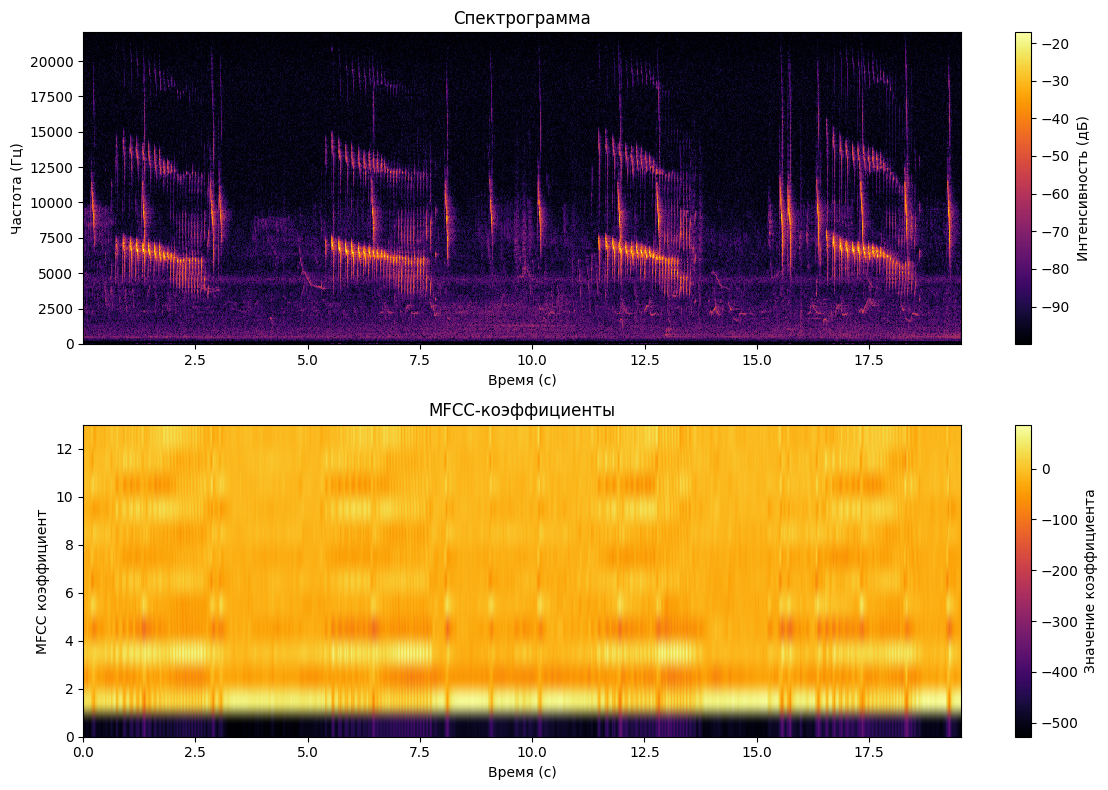

In [40]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Спектрограмма
Sxx, tn, fn, ext = sound.spectrogram(s, fs, nperseg=1024, noverlap=512)
im1 = ax1.pcolormesh(tn, fn, 10 * np.log10(Sxx + 1e-10), shading='auto', cmap='inferno')
ax1.set_xlabel('Время (с)')
ax1.set_ylabel('Частота (Гц)')
ax1.set_title('Спектрограмма')
plt.colorbar(im1, ax=ax1, label='Интенсивность (дБ)')

# Вычисление MFCC
mfcc = librosa.feature.mfcc(y=s, sr=fs, n_mfcc=13)  # форма (13, время)
# Визуализация MFCC
im2 = ax2.imshow(mfcc, aspect='auto', origin='lower', cmap='inferno',
                 extent=[0, len(s)/fs, 0, mfcc.shape[0]])
ax2.set_xlabel('Время (с)')
ax2.set_ylabel('MFCC коэффициент')
ax2.set_title('MFCC-коэффициенты')
plt.colorbar(im2, ax=ax2, label='Значение коэффициента')

plt.tight_layout()
plt.show()

In [41]:
# diagrams.onprem.compute.Server – иконка сервера (on‑premise compute)
# Используется для сервисов, которые выполняют обработку данных
# (например, audio_preprocessor, trainer, inference)

# diagrams.onprem.database.PostgreSQL – иконка базы данных PostgreSQL
# Подходит для сервисов хранения (например, audio_db)

# diagrams.saas.chat.Telegram – иконка Telegram (SaaS, чат)
# Используется для сервиса отправки уведомлений (notifier)

# diagrams.onprem.workflow.Airflow – иконка оркестратора задач (Apache Airflow)
# Используется для сервисов, которые управляют бизнес-логикой,
# очередностью и состоянием процесса (например, event_manager – контроль
# первого утреннего уведомления)

# depends_on должен указывать от кого получает данные сервис!!!

%%writefile docker-compose.yml
---
services:
  # Сбор аудио с микрофона
  audio_collector:
    container_name: audio_collector
    depends_on:
      - audio_db
    labels:
      "docker_compose_diagram.cluster": "сбор и хранение аудио"
      "docker_compose_diagram.icon": "diagrams.onprem.compute.Server"
      "docker_compose_diagram.description": "Запись аудио"

  # Хранилище wav-файлов
  audio_db:
    container_name: audio_db
    labels:
      "docker_compose_diagram.cluster": "сбор и хранение аудио"
      "docker_compose_diagram.icon": "diagrams.onprem.database.PostgreSQL"
      "docker_compose_diagram.description": "Хранилище wav"

  # Извлечение MFCC-признаков
  feature_extractor:
    container_name: feature_extractor
    depends_on:
      - audio_db
    labels:
      "docker_compose_diagram.cluster": "извлечение признаков"
      "docker_compose_diagram.icon": "diagrams.onprem.compute.Server"
      "docker_compose_diagram.description": "Вычисление MFCC"

  # Обучение сверточной нейросети
  trainer:
    container_name: trainer
    depends_on:
      - feature_extractor
      - model_storage
    labels:
      "docker_compose_diagram.cluster": "обучение модели"
      "docker_compose_diagram.icon": "diagrams.onprem.compute.Server"
      "docker_compose_diagram.description": "Обучение CNN"

  # Хранение весов моделей
  model_storage:
    container_name: model_storage
    labels:
      "docker_compose_diagram.cluster": "хранение моделей"
      "docker_compose_diagram.icon": "diagrams.onprem.compute.Server"
      "docker_compose_diagram.description": "Хранение весов"

  # Регистрация и версионирование моделей
  model_registry:
    container_name: model_registry
    depends_on:
      - trainer
      - model_storage
    labels:
      "docker_compose_diagram.cluster": "хранение моделей"
      "docker_compose_diagram.icon": "diagrams.onprem.compute.Server"
      "docker_compose_diagram.description": "Регистрация\nмоделей"

  # Инференс – детекция пения
  inference:
    container_name: inference
    depends_on:
      - model_registry
      - feature_extractor
    labels:
      "docker_compose_diagram.cluster": "инференс"
      "docker_compose_diagram.icon": "diagrams.onprem.compute.Server"
      "docker_compose_diagram.description": "Детекция пения"

  # Менеджер состояний (первое утреннее уведомление)
  event_manager:
    container_name: event_manager
    depends_on:
      - inference
      - audio_db
    labels:
      "docker_compose_diagram.cluster": "бизнес-логика"
      "docker_compose_diagram.icon": "diagrams.onprem.workflow.Airflow"
      "docker_compose_diagram.description": "Первое\nутреннее\nуведомление"

  # Telegram-бот для отправки сообщений
  notifier:
    container_name: notifier
    depends_on:
      - event_manager
    labels:
      "docker_compose_diagram.cluster": "уведомления"
      "docker_compose_diagram.icon": "diagrams.saas.chat.Telegram"
      "docker_compose_diagram.description": "Отправка\nв Telegram"

Overwriting docker-compose.yml


In [42]:
# Проверка синтаксиса YAML
!yamllint docker-compose.yml

In [43]:
!compose-diagram --file docker-compose.yml --direction=LR --nodesep=1.2

File docker-compose.yml has been found. Reading! 📗 
Service: audio_collector
   Service: {'docker_compose_diagram.cluster': 'сбор и хранение аудио', 
'docker_compose_diagram.icon': 'diagrams.onprem.compute.Server', 
'docker_compose_diagram.description': 'Запись аудио'}
Service: audio_db
   Service: {'docker_compose_diagram.cluster': 'сбор и хранение аудио', 
'docker_compose_diagram.icon': 'diagrams.onprem.database.PostgreSQL', 
'docker_compose_diagram.description': 'Хранилище wav'}
Service: feature_extractor
   Service: {'docker_compose_diagram.cluster': 'извлечение признаков', 
'docker_compose_diagram.icon': 'diagrams.onprem.compute.Server', 
'docker_compose_diagram.description': 'Вычисление MFCC'}
Service: trainer
   Service: {'docker_compose_diagram.cluster': 'обучение модели', 
'docker_compose_diagram.icon': 'diagrams.onprem.compute.Server', 
'docker_compose_diagram.description': 'Обучение CNN'}
Service: model_storage
   Service: {'docker_compose_diagram.cluster': 'хранение моделей

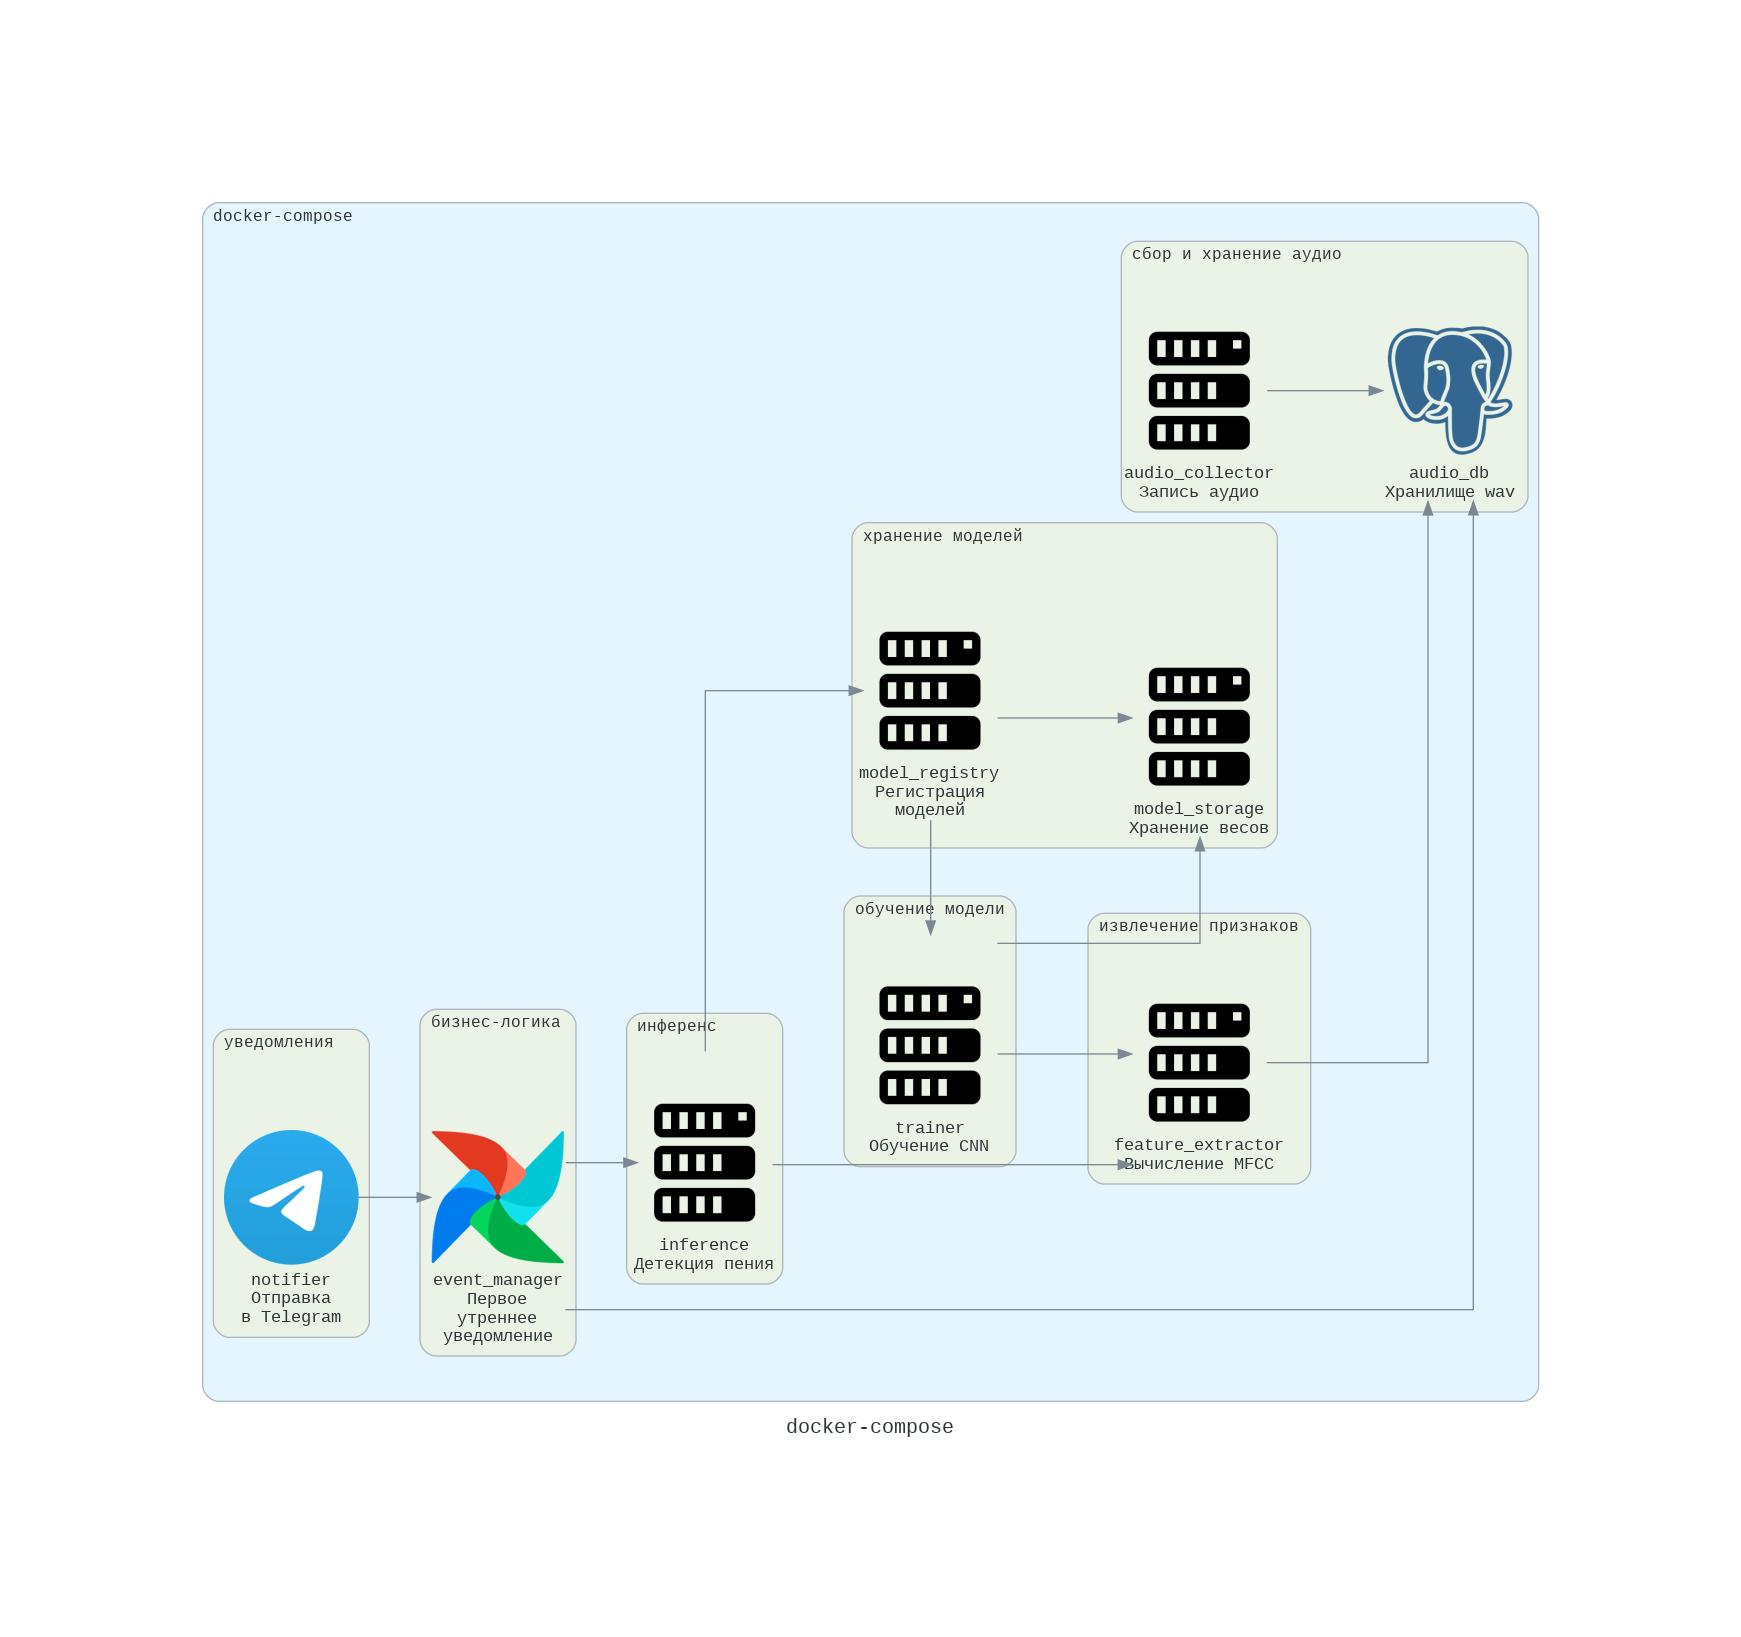

In [44]:
from IPython.display import Image, display
image_path = '/content/docker-compose.png'
display(Image(filename=image_path))

**Связь**

1. Коллектор пишет wav-файлы в БД, поэтому БД должна быть запущена до начала записи: audio_collector -> audio_db

2. Экстрактор читает wav из БД, следовательно, БД должна быть готова: feature_extractor -> audio_db

3. Тренер получает MFCC-снимки от экстрактора. Экстрактор должен быть запущен и обработать данные: trainer -> feature_extractor

4. Тренер сохраняет веса обученной модели в хранилище. Хранилище должно быть доступно: trainer -> model_storage.

5. Реестр получает информацию о новой версии модели от тренера: model_registry -> trainer

6. Реестр читает артефакты модели из хранилища: model_registry -> model_storage

7. Инференс‑сервис загружает актуальную модель из реестра: inference -> model_registry

8. Инференс получает MFCC-снимки от экстрактора для детекции в реальном времени: inference -> feature_extractor

9. Менеджер событий получает сигнал о детекции от инференса: event_manager -> inference

10. Менеджер хранит в БД флаг «первое утреннее уведомление уже отправлено сегодня»: event_manager -> audio_db

11. Telegram-бот получает команду на отправку от менеджера событий: notifier -> event_manager

**Вывод**

Спроектирована ML‑система для детекции утреннего пения жаворонка с отправкой уведомлений в Telegram. Архитектура включает 9 сервисов, связанных через depends_on в docker-compose.yml. Все 11 связей отражают порядок запуска, необходимый для корректного потока данных: аудиоколлектор пишет wav в БД -> экстрактор читает WAV и вычисляет MFCC‑признаки -> тренер получает признаки и сохраняет веса модели в хранилище -> реестр версионирует модель -> инференс загружает модель и признаки для детекции -> менеджер событий получает сигнал и проверяет флаг первого уведомления в БД -> Telegram‑бот отправляет сообщение.